# Day 27 — SHAP & Model Explainability
### SHAP Values · Feature Importance · Waterfall · Beeswarm · Force Plots

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import warnings

warnings.filterwarnings("ignore")

# Install SHAP if needed
try:
    import shap

    print(f"SHAP: {shap.__version__} ✅")
except ImportError:
    import subprocess

    subprocess.run(["pip", "install", "shap"], capture_output=True)
    import shap

    print(f"SHAP: {shap.__version__} ✅ (just installed)")

plt.style.use("dark_background")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)
df["FareLog"] = np.log1p(df["Fare"])
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
title_map = {"Mr": "Mr", "Miss": "Miss", "Mrs": "Mrs", "Master": "Master"}
df["Title"] = df["Title"].map(title_map).fillna("Other")
for t in ["Mr", "Mrs", "Miss", "Master"]:
    df[f"Title_{t}"] = (df["Title"] == t).astype(int)

features = [
    "Pclass",
    "Age",
    "FareLog",
    "FamilySize",
    "IsAlone",
    "Sex_encoded",
    "Title_Mr",
    "Title_Mrs",
    "Title_Miss",
]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, min_samples_leaf=4, random_state=42)
rf.fit(X_train, y_train)
auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f"\nRandom Forest AUC: {auc:.4f}")
print(f"Features: {features}")
print("Ready! ✅")

SHAP: 0.51.0 ✅ (just installed)

Random Forest AUC: 0.8492
Features: ['Pclass', 'Age', 'FareLog', 'FamilySize', 'IsAlone', 'Sex_encoded', 'Title_Mr', 'Title_Mrs', 'Title_Miss']
Ready! ✅


## 2. What is SHAP?

In [2]:
print("=" * 55)
print("           WHAT IS SHAP?")
print("=" * 55)
print("""
SHAP = SHapley Additive exPlanations

WHY EXPLAINABILITY MATTERS:
  - Regulators require explanations (GDPR Article 22)
  - Doctors need to understand why a diagnosis was made
  - Banks must explain why a loan was rejected
  - Data Scientists need to debug model behaviour
  - Clients need to trust the model

THE BLACK BOX PROBLEM:
  Random Forest, XGBoost, Neural Networks → black boxes
  High accuracy but NO explanation WHY

SHAP SOLUTION:
  Based on game theory (Shapley values from cooperative game theory)
  Fairly distributes the model's prediction among features

SHAP VALUE MEANING:
  For each prediction, each feature gets a SHAP value:
  Positive SHAP → feature INCREASED survival probability
  Negative SHAP → feature DECREASED survival probability
  Large |SHAP| → feature had BIG impact on this prediction
  SHAP ≈ 0     → feature had little impact on this prediction

SHAP GUARANTEE:
  Sum of all SHAP values = prediction - baseline prediction
  (baseline = average prediction across all samples)

THREE KEY PLOTS:
  1. Summary/Beeswarm — overall feature importance + direction
  2. Waterfall         — single prediction explained step by step
  3. Bar plot          — mean absolute SHAP (global importance)
""")

           WHAT IS SHAP?

SHAP = SHapley Additive exPlanations

WHY EXPLAINABILITY MATTERS:
  - Regulators require explanations (GDPR Article 22)
  - Doctors need to understand why a diagnosis was made
  - Banks must explain why a loan was rejected
  - Data Scientists need to debug model behaviour
  - Clients need to trust the model

THE BLACK BOX PROBLEM:
  Random Forest, XGBoost, Neural Networks → black boxes
  High accuracy but NO explanation WHY

SHAP SOLUTION:
  Based on game theory (Shapley values from cooperative game theory)
  Fairly distributes the model's prediction among features

SHAP VALUE MEANING:
  For each prediction, each feature gets a SHAP value:
  Positive SHAP → feature INCREASED survival probability
  Negative SHAP → feature DECREASED survival probability
  Large |SHAP| → feature had BIG impact on this prediction
  SHAP ≈ 0     → feature had little impact on this prediction

SHAP GUARANTEE:
  Sum of all SHAP values = prediction - baseline prediction
  (baseline = 

## 3. Computing SHAP Values

In [ ]:
print("=" * 55)
print("        COMPUTING SHAP VALUES")
print("=" * 55)

# Create SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

print(f"\nSHAP values shape: {shap_values.values.shape}")
print(f"  → {shap_values.values.shape[0]} test samples")
print(f"  → {shap_values.values.shape[1]} features")
print(f"  → {shap_values.values.shape[2]} classes (0=Died, 1=Survived)")

# Look at SHAP values for class 1 (Survived)
shap_survived = shap_values[:, :, 1]

print(f"\nBaseline prediction (average): {shap_values.base_values[0,1]:.4f}")
print(f"  = {shap_values.base_values[0,1]*100:.1f}% survival probability")

# Show SHAP breakdown for first test passenger
print(f"\n--- SHAP breakdown for Passenger 1 ---")
passenger = X_test.iloc[0]
shap_vals = shap_survived.values[0]
prediction = rf.predict_proba(X_test.iloc[[0]])[0, 1]

print(f"Actual outcome: {'Survived' if y_test.iloc[0]==1 else 'Died'}")
print(f"Model prediction: {prediction:.4f} ({prediction*100:.1f}% survival)")
print(f"Baseline: {shap_values.base_values[0,1]:.4f}")
print(f"\nSHAP value breakdown:")
print(f"{'Feature':<15} {'Value':<12} {'SHAP':<10} {'Direction'}")
print("-" * 50)
for feat, val, shap_v in sorted(
    zip(features, passenger.values, shap_vals), key=lambda x: abs(x[2]), reverse=True
):
    direction = "↑ helps survival" if shap_v > 0 else "↓ hurts survival"
    print(f"{feat:<15} {val:<12.3f} {shap_v:<10.4f} {direction}")
print(
    f"\nSum of SHAP + baseline = {shap_vals.sum() + shap_values.base_values[0,1]:.4f}"
)
print(f"Model prediction       = {prediction:.4f}")
print(f"✅ Match confirmed!")

        COMPUTING SHAP VALUES

SHAP values shape: (179, 9, 2)
  → 179 test samples
  → 9 features
  → 2 classes (0=Died, 1=Survived)

Baseline prediction (average): 0.3850
  = 38.5% survival probability

--- SHAP breakdown for Passenger 1 ---
Actual outcome: Died
Model prediction: 0.1678 (16.8% survival)
Baseline: 0.3850

SHAP value breakdown:
Feature         Value        SHAP       Direction
--------------------------------------------------
Sex_encoded     0.000        -0.0822    ↓ hurts survival
Title_Mr        1.000        -0.0820    ↓ hurts survival
Pclass          3.000        -0.0438    ↓ hurts survival
FamilySize      3.000        0.0153     ↑ helps survival
Title_Mrs       0.000        -0.0152    ↓ hurts survival
Title_Miss      0.000        -0.0149    ↓ hurts survival
IsAlone         0.000        0.0038     ↑ helps survival
FareLog         3.225        0.0021     ↑ helps survival
Age             24.000       -0.0002    ↓ hurts survival

Sum of SHAP + baseline = 0.1678
Model p

## 4. SHAP Visualisations

Generating SHAP plots...


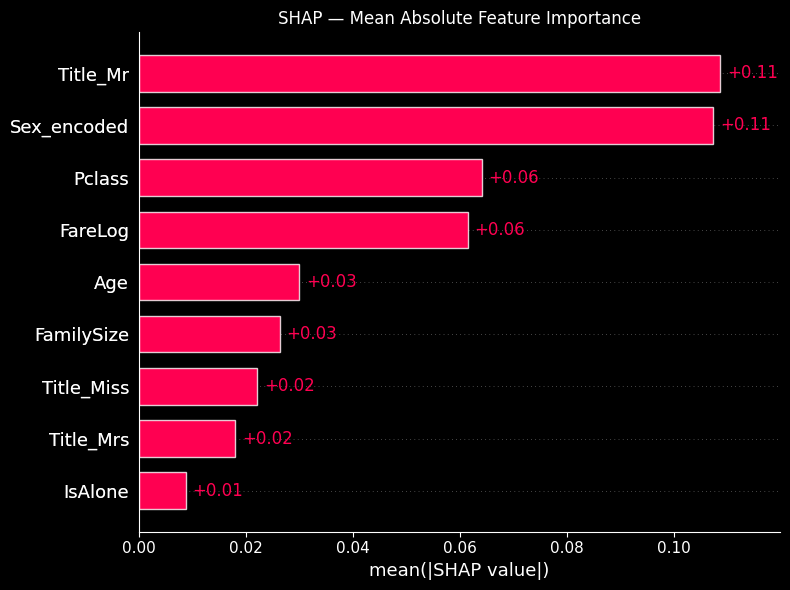

✅ Bar plot done


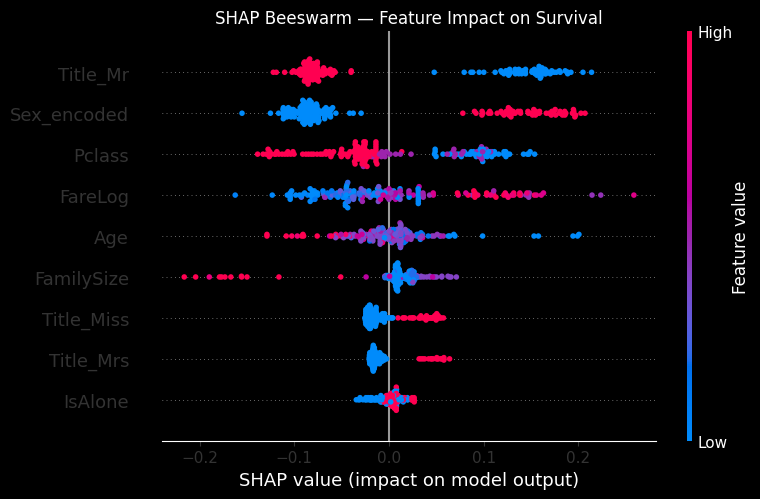

✅ Beeswarm plot done


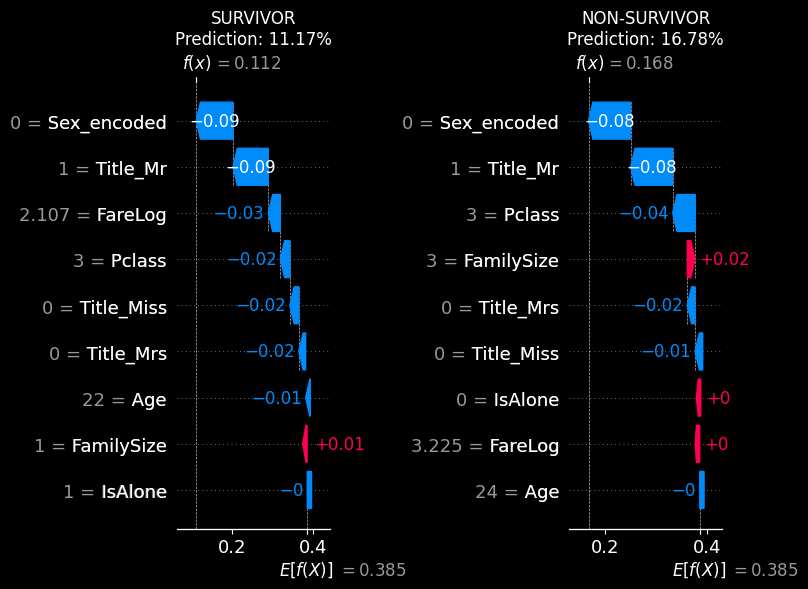

✅ Waterfall plots done


In [ ]:
print("Generating SHAP plots...")

# Plot 1 — Bar plot (global importance)
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_survived, show=False)
plt.title("SHAP — Mean Absolute Feature Importance")
plt.tight_layout()
plt.savefig(
    "shap_bar.png", dpi=100, bbox_inches="tight", facecolor="#1a1a2e", edgecolor="none"
)
plt.show()
print("✅ Bar plot done")

# Plot 2 — Beeswarm (summary)
plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_survived, show=False)
plt.title("SHAP Beeswarm — Feature Impact on Survival")
plt.tight_layout()
plt.savefig(
    "shap_beeswarm.png",
    dpi=100,
    bbox_inches="tight",
    facecolor="#1a1a2e",
    edgecolor="none",
)
plt.show()
print("✅ Beeswarm plot done")

# Plot 3 — Waterfall for specific passengers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Find a survivor and a non-survivor
survivor_idx = y_test[y_test == 1].index[0]
died_idx = y_test[y_test == 0].index[0]
surv_pos = X_test.index.get_loc(survivor_idx)
died_pos = X_test.index.get_loc(died_idx)

for ax, pos, label in [
    (axes[0], surv_pos, "SURVIVOR"),
    (axes[1], died_pos, "NON-SURVIVOR"),
]:
    plt.sca(ax)
    shap.plots.waterfall(shap_survived[pos], show=False)
    ax.set_title(
        f"{label}\nPrediction: {rf.predict_proba(X_test.iloc[[pos]])[0,1]:.2%}"
    )

plt.tight_layout()
plt.savefig(
    "shap_waterfall.png",
    dpi=100,
    bbox_inches="tight",
    facecolor="#1a1a2e",
    edgecolor="none",
)
plt.show()
print("✅ Waterfall plots done")

## 5. SHAP Deep Dive — Correct Predictions

In [ ]:
print("=" * 55)
print("      SHAP DEEP DIVE — HIGH vs LOW SURVIVAL")
print("=" * 55)

# Find high and low confidence correct predictions
y_prob_all = rf.predict_proba(X_test)[:, 1]
y_pred_all = rf.predict(X_test)

# Find a high-confidence survivor prediction
correct_survivors = X_test[(y_test == 1) & (y_prob_all > 0.7)]
correct_died = X_test[(y_test == 0) & (y_prob_all < 0.3)]

print(f"High-confidence survivors (prob>0.7): {len(correct_survivors)}")
print(f"High-confidence non-survivors (prob<0.3): {len(correct_died)}")

# Show SHAP for top survivor
if len(correct_survivors) > 0:
    surv_idx = correct_survivors.index[0]
    surv_pos = X_test.index.get_loc(surv_idx)
    surv_prob = y_prob_all[surv_pos]
    surv_shap = shap_survived.values[surv_pos]

    print(f"\n--- High-confidence SURVIVOR (prob={surv_prob:.2%}) ---")
    print(f"Passenger features:")
    for feat, val in zip(features, X_test.iloc[surv_pos].values):
        print(f"  {feat}: {val:.3f}")
    print(f"\nSHAP values (sorted by impact):")
    for feat, shap_v in sorted(
        zip(features, surv_shap), key=lambda x: abs(x[1]), reverse=True
    ):
        direction = "↑" if shap_v > 0 else "↓"
        bar = "█" * int(abs(shap_v) * 100)
        print(f"  {feat:<15} {shap_v:+.4f} {direction} {bar}")

# Feature interaction — SHAP dependence
print(f"\n--- SHAP values by Sex_encoded ---")
sex_shap = shap_survived.values[:, features.index("Sex_encoded")]
print(f"Male (Sex=0):   mean SHAP = {sex_shap[X_test['Sex_encoded']==0].mean():.4f}")
print(f"Female (Sex=1): mean SHAP = {sex_shap[X_test['Sex_encoded']==1].mean():.4f}")

print(f"\n--- SHAP values by Pclass ---")
pclass_shap = shap_survived.values[:, features.index("Pclass")]
for pc in [1, 2, 3]:
    mask = X_test["Pclass"] == pc
    mean_shap = pclass_shap[mask].mean()
    print(f"Class {pc}: mean SHAP = {mean_shap:+.4f}")

# Global summary
print(f"\n--- Global SHAP Summary ---")
mean_abs_shap = np.abs(shap_survived.values).mean(axis=0)
for feat, imp in sorted(zip(features, mean_abs_shap), key=lambda x: x[1], reverse=True):
    bar = "█" * int(imp * 200)
    print(f"  {feat:<15} {imp:.4f} {bar}")

      SHAP DEEP DIVE — HIGH vs LOW SURVIVAL
High-confidence survivors (prob>0.7): 38
High-confidence non-survivors (prob<0.3): 80

--- High-confidence SURVIVOR (prob=81.70%) ---
Passenger features:
  Pclass: 2.000
  Age: 36.000
  FareLog: 2.639
  FamilySize: 1.000
  IsAlone: 1.000
  Sex_encoded: 1.000
  Title_Mr: 0.000
  Title_Mrs: 0.000
  Title_Miss: 1.000

SHAP values (sorted by impact):
  Sex_encoded     +0.1964 ↑ ███████████████████
  Title_Mr        +0.1563 ↑ ███████████████
  Pclass          +0.1004 ↑ ██████████
  FareLog         -0.0429 ↓ ████
  Title_Miss      +0.0377 ↑ ███
  Age             -0.0241 ↓ ██
  FamilySize      +0.0201 ↑ ██
  Title_Mrs       -0.0135 ↓ █
  IsAlone         +0.0015 ↑ 

--- SHAP values by Sex_encoded ---
Male (Sex=0):   mean SHAP = -0.0858
Female (Sex=1): mean SHAP = 0.1489

--- SHAP values by Pclass ---
Class 1: mean SHAP = +0.0994
Class 2: mean SHAP = +0.0427
Class 3: mean SHAP = -0.0516

--- Global SHAP Summary ---
  Title_Mr        0.1086 ███████████

## 6. Key Takeaways — Day 27 🎯

### Why Explainability Matters
- GDPR Article 22 — right to explanation for automated decisions
- Medical/financial models MUST be explainable
- Helps debug models and find biases
- Builds trust with stakeholders

### What is SHAP?
- SHapley Additive exPlanations — based on game theory
- Fairly attributes prediction to each feature
- **SHAP Guarantee:** sum of SHAP values + baseline = prediction
- Works for ANY model (black box or not)

### SHAP Value Interpretation
- Positive SHAP → feature INCREASES the prediction
- Negative SHAP → feature DECREASES the prediction
- |SHAP| large → feature had big impact on this prediction
- SHAP ≈ 0 → feature had little impact

### Three Key Plots
| Plot | What it shows |
|---|---|
| Bar plot | Mean absolute SHAP — global feature importance |
| Beeswarm | Every sample — direction AND magnitude + feature value colour |
| Waterfall | Single prediction breakdown — step by step |

### Global SHAP Rankings (Titanic)
1. Title_Mr: 0.109 — gender proxy
2. Sex_encoded: 0.107 — gender direct
3. Pclass: 0.064 — wealth/class
4. FareLog: 0.062 — wealth proxy
5. Age: 0.030
6. FamilySize: 0.026
7. IsAlone: 0.009 — least important

### Key SHAP Insights
- Female SHAP: +0.149 vs Male SHAP: -0.086 → 23.5% gender swing!
- 1st class SHAP: +0.099 vs 3rd class: -0.052
- High-confidence survivor (Miss, 2nd class): 81.7% survival
- SHAP more honest than RF importance — accounts for correlations

### SHAP vs RF Feature Importance
- RF importance: Fare=0.133 (top!) — inflated by correlation with Pclass
- SHAP: Title_Mr=0.109, Sex=0.107 (top) — correctly attributes credit
- Always prefer SHAP over built-in feature importance!

### sklearn Functions
- `shap.TreeExplainer(model)` — fast explainer for tree models
- `explainer(X_test)` — compute SHAP values for all samples
- `shap_values[:,:,1]` — SHAP for class 1 (survived)
- `shap.plots.bar(shap_values)` — global importance bar plot
- `shap.plots.beeswarm(shap_values)` — summary beeswarm plot
- `shap.plots.waterfall(shap_values[i])` — single prediction waterfall
- `shap_values.base_values` — baseline prediction
- `shap_values.values` — array of SHAP values